 # Análisis ensemble de drop de presión — caso 9mm CFD

Este notebook compara las predicciones de presión con el drop de referencia CFD para cuatro pares de puntos sobre la centerline: (35,90), (35,138), (35,170) y (35,190).

Para cada drop se calcula el promedio $\mu$ entre semillas y su banda $\mu\pm1\sigma$, junto con métricas de error frente al CFD.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
})

## 1. Carga de semillas para un único drop

Se cargan automáticamente las exportaciones por semilla para el par seleccionado. En este análisis se usa `idxP1=35` e `idxP2=170`, que son los archivos disponibles en `pressure_train/results`.

In [2]:
import re

project_dir = Path("/proj/multipress/users/x_sebja/Exp_32_Jul_cfd")
experiment_dir = project_dir / "13mm_CFD"
results_dir = experiment_dir / "pressure_train" / "results"
output_dir = experiment_dir / "pressure_drop_ensemble_analysis_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

if not results_dir.exists():
    raise FileNotFoundError(f"No se encontró la carpeta de resultados: {results_dir}")

# Este notebook analiza un único drop entre los dos puntos seleccionados.
target_drop_pair = (35, 170)
target_drop_pairs = [target_drop_pair]
target_pair_set = {target_drop_pair}

filename_pattern = re.compile(
    r"pressure_drop_curves_(seed_\d{3}_\d{8}_\d{6})_cfd_idxP1_(\d+)_idxP2_(\d+)\.csv$"
)

curves_by_drop = {target_drop_pair: {}}
for csv_path in sorted(results_dir.glob("seed_*/exports/pressure_drop_curves_*.csv")):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue
    run_name = match.group(1)
    idx_p1 = int(match.group(2))
    idx_p2 = int(match.group(3))
    pair = (idx_p1, idx_p2)
    if pair != target_drop_pair:
        continue
    curves_by_drop[target_drop_pair][run_name] = pd.read_csv(csv_path)

if len(curves_by_drop[target_drop_pair]) == 0:
    raise FileNotFoundError(
        f"No se encontraron curvas para el drop idxP1={target_drop_pair[0]}, "
        f"idxP2={target_drop_pair[1]}"
    )

common_runs = sorted(curves_by_drop[target_drop_pair])
curves_by_drop[target_drop_pair] = {
    run_name: curves_by_drop[target_drop_pair][run_name]
    for run_name in common_runs
}

print(f"Proyecto: {project_dir}")
print(f"Resultados: {results_dir}")
print(f"Salida: {output_dir}")
print(
    f"Drop seleccionado: idxP1={target_drop_pair[0]}, "
    f"idxP2={target_drop_pair[1]}"
)
print(f"Semillas usadas ({len(common_runs)}):")
for run_name in common_runs:
    print(f" - {run_name}")

display(
    pd.DataFrame(
        [{
            "idx_p1": target_drop_pair[0],
            "idx_p2": target_drop_pair[1],
            "n_semillas": len(curves_by_drop[target_drop_pair]),
        }]
    )
)

Proyecto: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd
Resultados: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results
Salida: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_drop_ensemble_analysis_outputs
Drop seleccionado: idxP1=35, idxP2=170
Semillas usadas (5):
 - seed_001_20260816_163211
 - seed_002_20260816_163250
 - seed_003_20260816_163308
 - seed_004_20260816_163329
 - seed_005_20260816_163352


,idx_p1,idx_p2,n_semillas
0,35,170,5


## 2. Verificación y construcción del ensamble

Para cada drop se exige la misma malla temporal y la misma referencia CFD en todas las semillas. La desviación estándar usa `ddof=1` (muestral).

In [3]:
required_columns = [
    "time_s",
    "drop_model_total_mmHg",
    "drop_model_acc_mmHg",
    "drop_model_adv_mmHg",
    "drop_model_vis_mmHg",
    "drop_cfd_reference_mmHg",
]

column_map = {
    "total": "drop_model_total_mmHg",
    "acc": "drop_model_acc_mmHg",
    "adv": "drop_model_adv_mmHg",
    "vis": "drop_model_vis_mmHg",
}

def build_ensemble_for_drop(curves_for_drop):
    reference_df = next(iter(curves_for_drop.values()))
    time_s = reference_df["time_s"].to_numpy(float)
    clinical = reference_df["drop_cfd_reference_mmHg"].to_numpy(float)

    for run_name, frame in curves_for_drop.items():
        absent = sorted(set(required_columns) - set(frame.columns))
        if absent:
            raise ValueError(f"{run_name}: faltan columnas {absent}")
        if not np.allclose(frame["time_s"], time_s, rtol=0, atol=1e-12):
            raise ValueError(f"{run_name}: la malla temporal no coincide")
        if not np.allclose(frame["drop_cfd_reference_mmHg"], clinical, rtol=0, atol=1e-10):
            raise ValueError(f"{run_name}: la referencia CFD no coincide")

    stacks = {
        key: np.vstack([frame[column].to_numpy(float) for frame in curves_for_drop.values()])
        for key, column in column_map.items()
    }
    means = {key: values.mean(axis=0) for key, values in stacks.items()}
    ddof = 1 if len(curves_for_drop) > 1 else 0
    stds = {key: values.std(axis=0, ddof=ddof) for key, values in stacks.items()}
    phase = (time_s - time_s[0]) / (time_s[-1] - time_s[0])

    return {
        "time_s": time_s,
        "clinical": clinical,
        "phase": phase,
        "stacks": stacks,
        "means": means,
        "stds": stds,
    }

analysis_by_drop = {}
for pair in target_drop_pairs:
    analysis_by_drop[pair] = build_ensemble_for_drop(curves_by_drop[pair])

print("Análisis construido para el drop seleccionado.")
for pair in target_drop_pairs:
    info = analysis_by_drop[pair]
    print(
        f"idxP1={pair[0]}, idxP2={pair[1]} -> puntos={len(info['time_s'])}, "
        f"duración={info['time_s'][-1] - info['time_s'][0]:.4f} s"
    )

Análisis construido para el drop seleccionado.
idxP1=35, idxP2=170 -> puntos=28, duración=0.7992 s


## 3. Curva promedio y banda de incertidumbre

Las líneas discontinuas muestran el promedio de cada contribución física. Cada contribución y el drop total incluyen su propia franja $\mu\pm1\sigma$, calculada entre las ejecuciones seleccionadas.

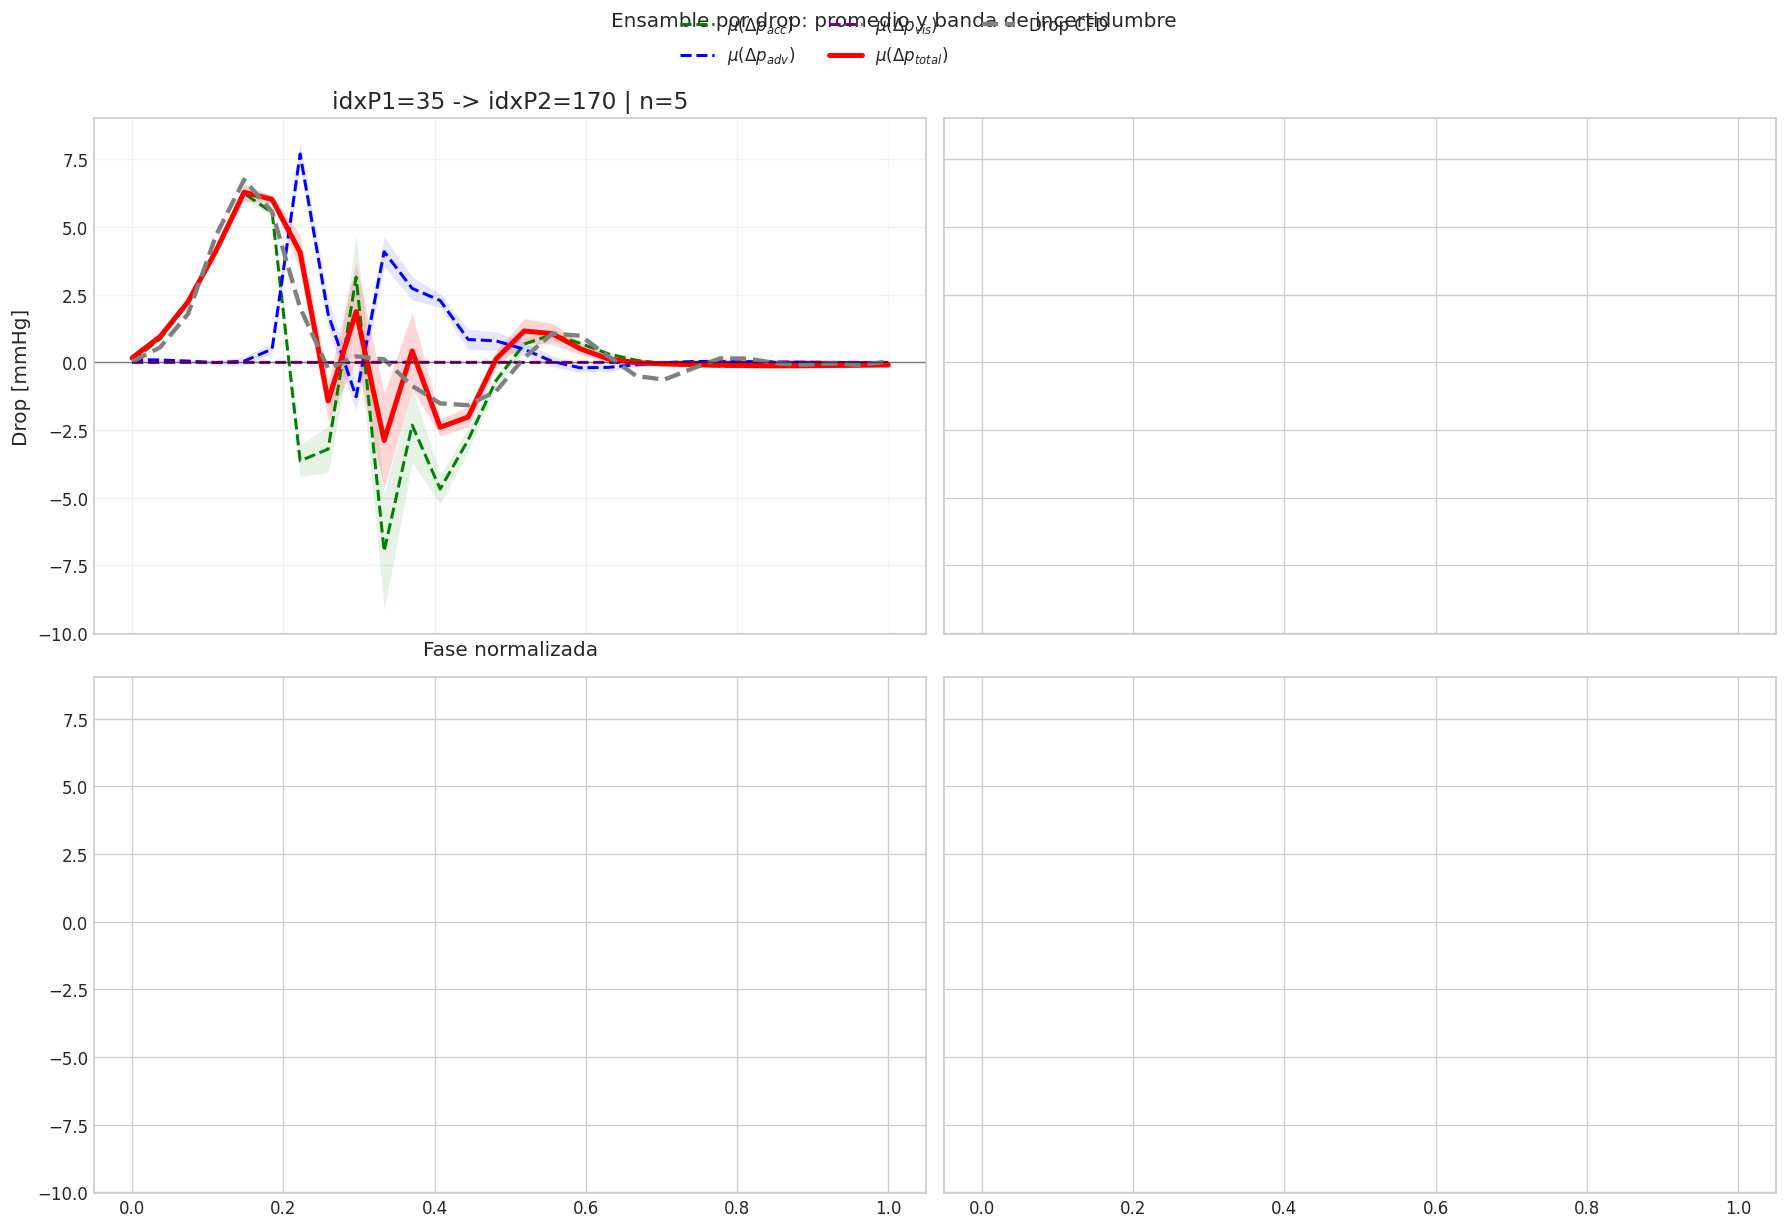

Figura guardada en: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_drop_ensemble_analysis_outputs/pressure_drop_ensemble_phase_all_drops.png


In [4]:
component_styles = {
    "acc": ("green", r"$\Delta p_{acc}$"),
    "adv": ("blue", r"$\Delta p_{adv}$"),
    "vis": ("purple", r"$\Delta p_{vis}$"),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, pair in zip(axes, target_drop_pairs):
    analysis = analysis_by_drop[pair]
    phase = analysis["phase"]
    clinical = analysis["clinical"]
    means = analysis["means"]
    stds = analysis["stds"]

    for key, (color, label) in component_styles.items():
        ax.fill_between(
            phase,
            means[key] - stds[key],
            means[key] + stds[key],
            color=color,
            alpha=0.10,
            linewidth=0,
        )
    ax.fill_between(
        phase,
        means["total"] - stds["total"],
        means["total"] + stds["total"],
        color="red",
        alpha=0.16,
        linewidth=0,
    )

    ax.plot(phase, means["acc"], "--", color="green", lw=1.8, label=r"$\mu(\Delta p_{acc})$")
    ax.plot(phase, means["adv"], "--", color="blue", lw=1.8, label=r"$\mu(\Delta p_{adv})$")
    ax.plot(phase, means["vis"], "--", color="purple", lw=1.8, label=r"$\mu(\Delta p_{vis})$")
    ax.plot(phase, means["total"], color="red", lw=3.0, label=r"$\mu(\Delta p_{total})$")
    ax.plot(phase, clinical, "--", color="gray", lw=2.6, label="Drop CFD")

    ax.axhline(0, color="black", lw=0.8, alpha=0.5)
    ax.set_title(f"idxP1={pair[0]} -> idxP2={pair[1]} | n={len(curves_by_drop[pair])}")
    ax.set_xlabel("Fase normalizada")
    ax.set_ylabel("Drop [mmHg]")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", framealpha=0.95)
fig.suptitle("Ensamble por drop: promedio y banda de incertidumbre", y=1.02)
fig.tight_layout()

figure_path = output_dir / "pressure_drop_ensemble_phase_all_drops.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {figure_path}")

### La misma curva en tiempo real

La fase normalizada se define como $\phi=(t-t_0)/(t_f-t_0)$. En esta sección se muestran exactamente las mismas curvas, pero en eje temporal real (segundos).

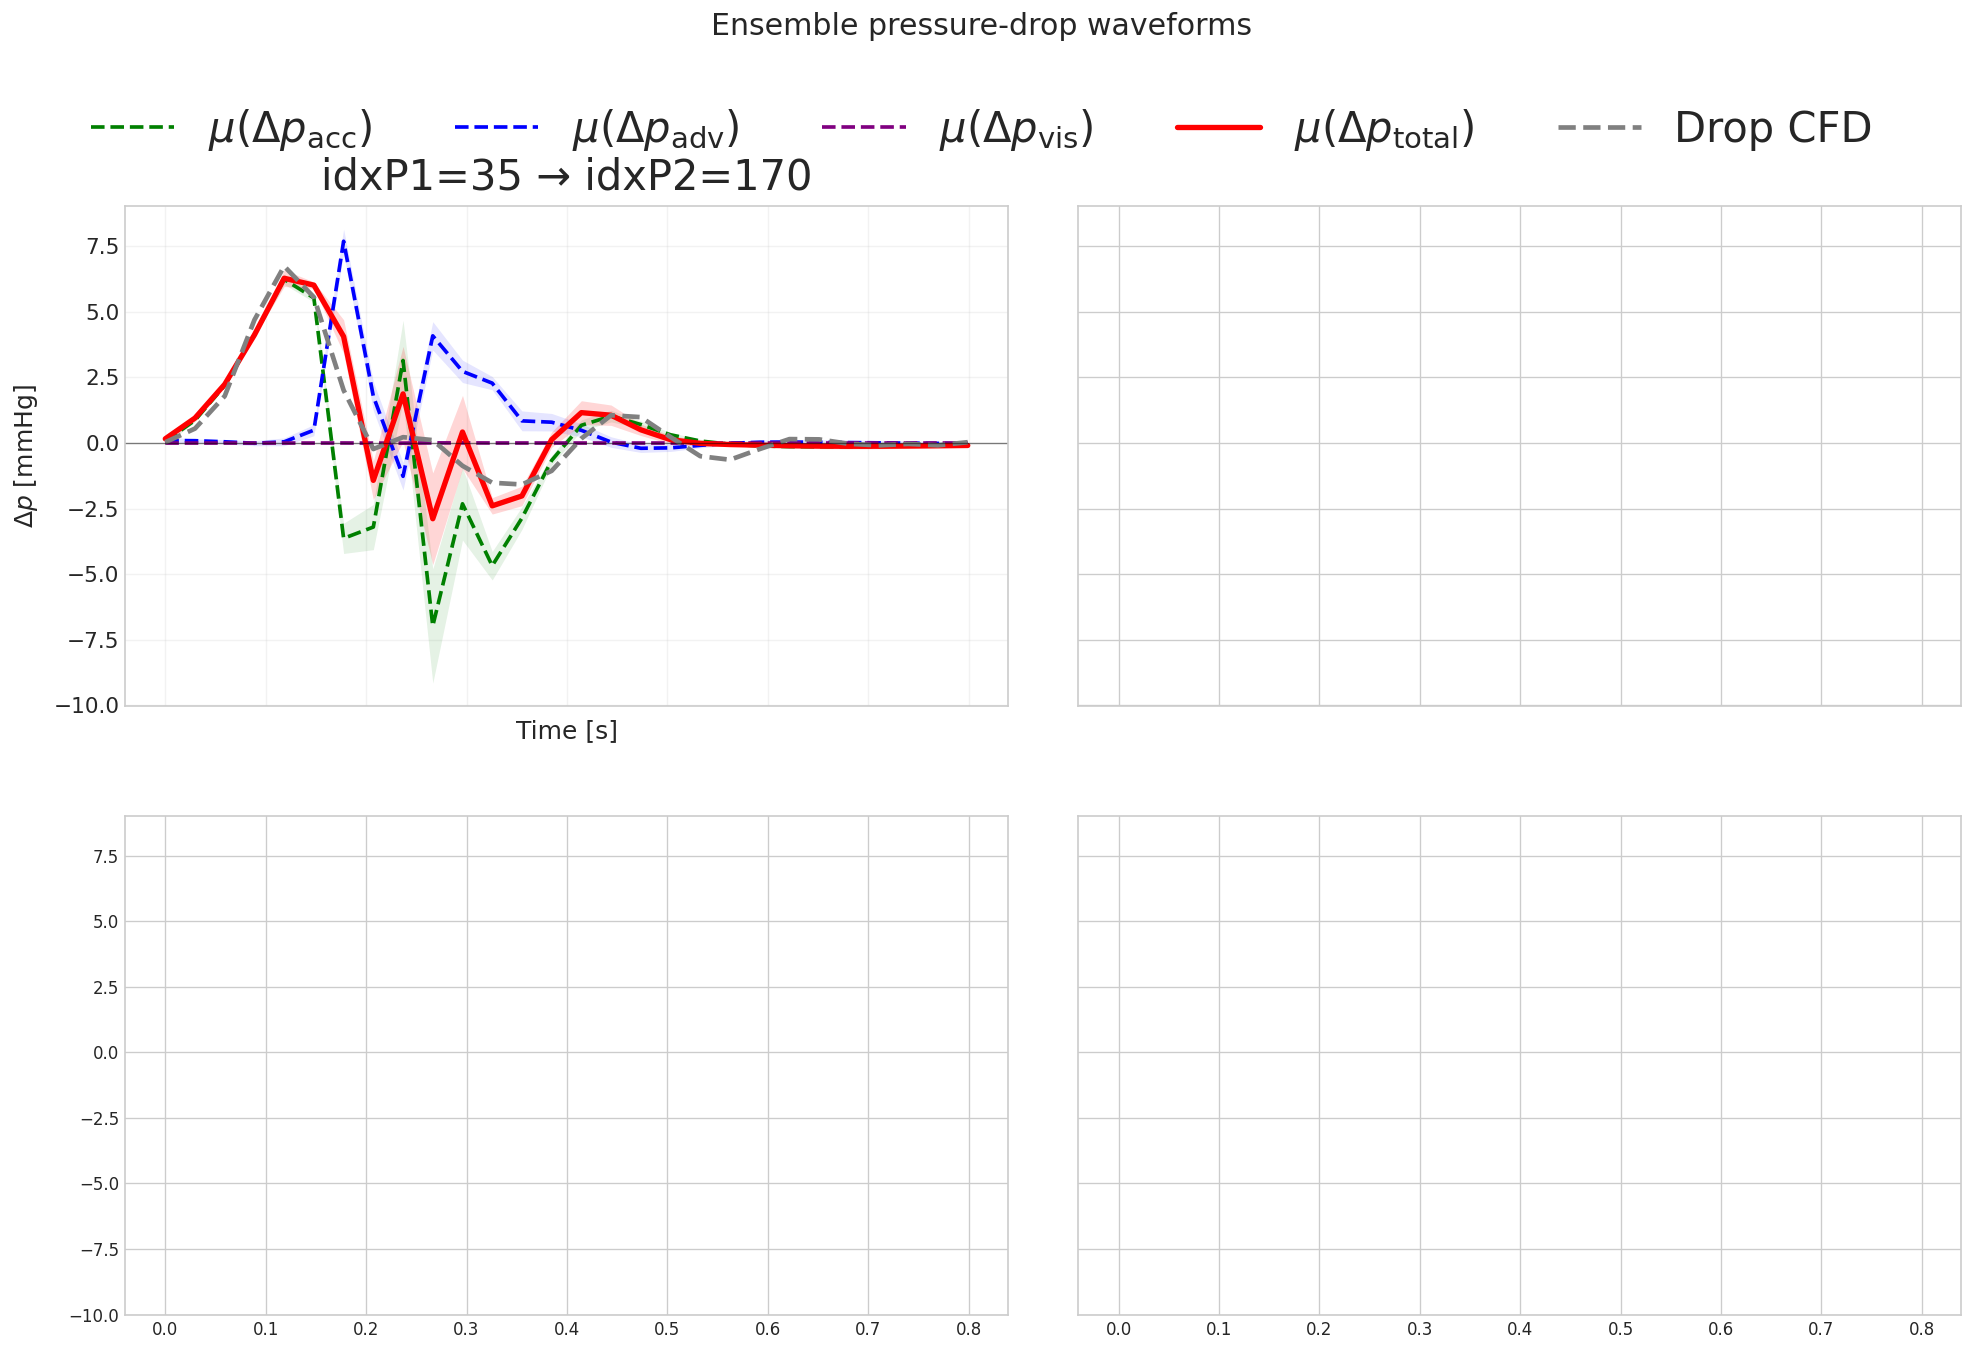

Figura guardada en: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_drop_ensemble_analysis_outputs/pressure_drop_ensemble_time_all_drops.png


In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 12),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

# Tamaños globales
title_fontsize = 25
label_fontsize = 15
tick_fontsize = 13
legend_fontsize = 25
suptitle_fontsize = 18

for ax, pair in zip(axes, target_drop_pairs):
    analysis = analysis_by_drop[pair]

    time_s = analysis["time_s"]
    clinical = analysis["clinical"]
    means = analysis["means"]
    stds = analysis["stds"]

    for key, (color, label) in component_styles.items():
        ax.fill_between(
            time_s,
            means[key] - stds[key],
            means[key] + stds[key],
            color=color,
            alpha=0.10,
            linewidth=0,
        )

    ax.fill_between(
        time_s,
        means["total"] - stds["total"],
        means["total"] + stds["total"],
        color="red",
        alpha=0.16,
        linewidth=0,
    )

    ax.plot(
        time_s,
        means["acc"],
        "--",
        color="green",
        lw=2.2,
        label=r"$\mu(\Delta p_{\mathrm{acc}})$",
    )

    ax.plot(
        time_s,
        means["adv"],
        "--",
        color="blue",
        lw=2.2,
        label=r"$\mu(\Delta p_{\mathrm{adv}})$",
    )

    ax.plot(
        time_s,
        means["vis"],
        "--",
        color="purple",
        lw=2.2,
        label=r"$\mu(\Delta p_{\mathrm{vis}})$",
    )

    ax.plot(
        time_s,
        means["total"],
        color="red",
        lw=3.2,
        label=r"$\mu(\Delta p_{\mathrm{total}})$",
    )

    ax.plot(
        time_s,
        clinical,
        "--",
        color="gray",
        lw=2.8,
        label="Drop CFD",
    )

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5,
    )

    ax.set_title(
        f"idxP1={pair[0]} → idxP2={pair[1]}",
        fontsize=title_fontsize,
        pad=10,
    )

    ax.set_xlabel(
        "Time [s]",
        fontsize=label_fontsize,
        labelpad=8,
    )

    ax.set_ylabel(
        r"$\Delta p$ [mmHg]",
        fontsize=label_fontsize,
        labelpad=8,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_fontsize,
    )

    ax.grid(
        True,
        alpha=0.25,
    )

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    fontsize=legend_fontsize,
    framealpha=0.95,
)

fig.suptitle(
    "Ensemble pressure-drop waveforms",
    fontsize=suptitle_fontsize,
    y=0.995,
)

fig.subplots_adjust(
    top=0.86,
    bottom=0.09,
    left=0.08,
    right=0.98,
    hspace=0.22,
    wspace=0.08,
)

time_figure_path = (
    output_dir
    / "pressure_drop_ensemble_time_all_drops.png"
)

fig.savefig(
    time_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figura guardada en: {time_figure_path}"
)

# Case 35 -> 170

In [6]:
from matplotlib.legend_handler import HandlerTuple

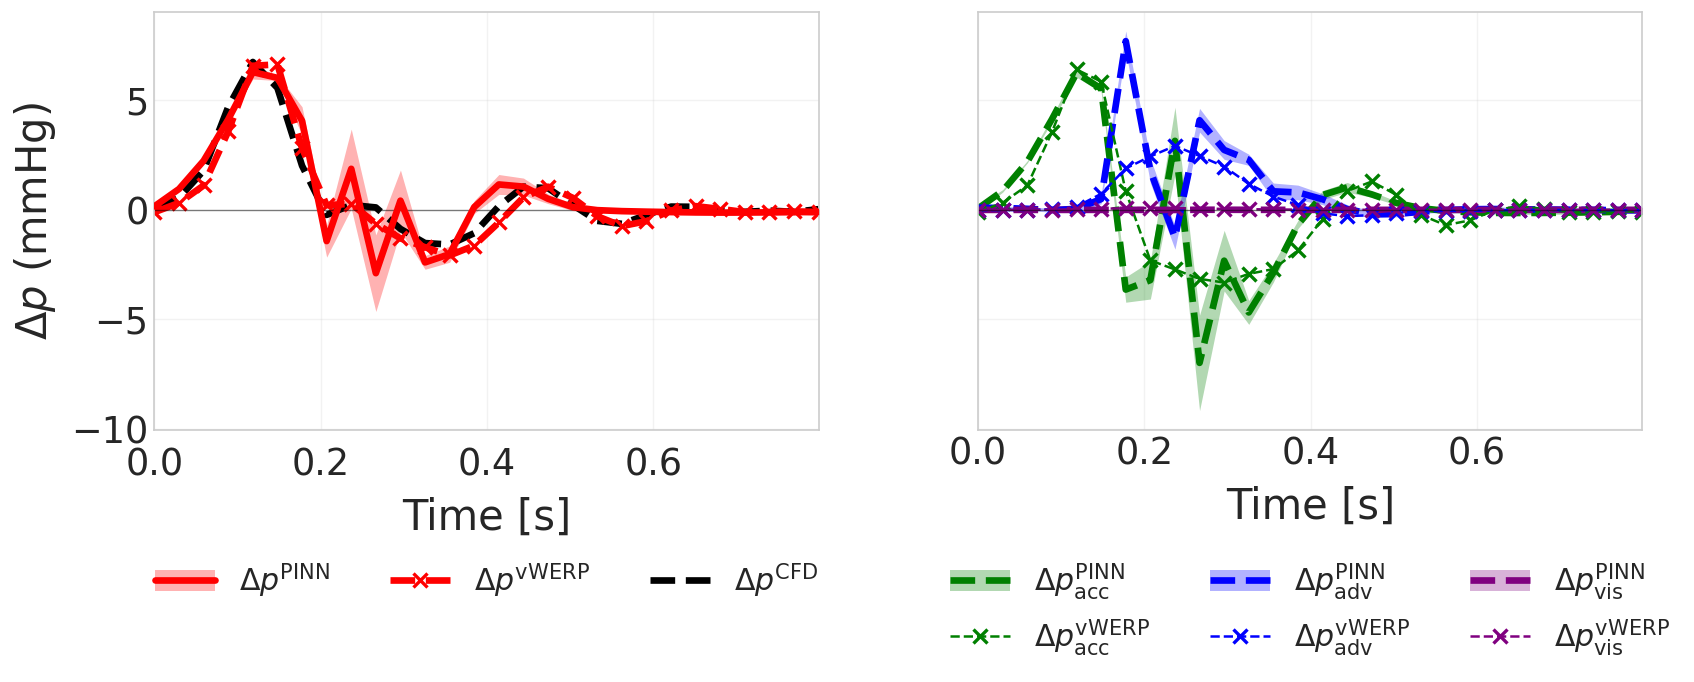

Figura guardada en: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_drop_ensemble_analysis_outputs/pressure_drop_two_panels_idx35_idx170.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# ============================================================
# vWERP
# ============================================================


# delta_time_vwerp = np.linspace(0.0, 0.8, 27)

delta_p_total = np.array([
     -0.106063, 0.314805,  1.113069,  3.577692,  6.573969,  6.634315,
     2.813989,  0.213196,  0.274139, -0.632469, -1.300531,
    -1.705075, -2.077733, -1.629068, -0.575986,  0.570239,
     1.055947,  0.550850, -0.290865, -0.741473, -0.515199,
    -0.029657,  0.168410,  0.040505, -0.102495, -0.096366,
    -0.069594, -0.106063,
])

delta_p_acc = np.array([
     -0.093705, 0.323715,  1.115054,  3.543449,  6.403375,  5.851357,
     0.850149, -2.307239, -2.719258, -3.149691, -3.317077,
    -2.921073, -2.702059, -1.852246, -0.418901,  0.856880,
     1.293964,  0.683412, -0.230876, -0.698762, -0.477127,
    -0.013006,  0.167271,  0.042174, -0.093766, -0.085689,
    -0.058607, -0.093705,
])

delta_p_adv = np.array([
    -0.014362, -0.010643, -0.005283,  0.025465,  0.146370,  0.731174,
     1.889855,  2.437913,  2.917343,  2.457964,  1.973624,
     1.187246,  0.605660,  0.214418, -0.158757, -0.287950,
    -0.242211, -0.138876, -0.066919, -0.049044, -0.043121,
    -0.020549, -0.002127, -0.004769, -0.011748, -0.013394,
    -0.013343, -0.014362,
])

delta_p_vis = np.array([
    0.002004, 0.001733, 0.003298, 0.008778, 0.024224, 0.051784,
    0.073986, 0.082523, 0.076054, 0.059258, 0.042923,
    0.028753, 0.018666, 0.008760, 0.001672, 0.001309,
    0.004194, 0.006315, 0.006930, 0.006333, 0.005049,
    0.003898, 0.003267, 0.003100, 0.003019, 0.002716,
    0.002356, 0.002004,
])


# ============================================================
# Caso seleccionado
# ============================================================

pair = (35, 170)
analysis = analysis_by_drop[pair]

time_s = np.asarray(analysis["time_s"])
clinical = np.asarray(analysis["clinical"])
means = analysis["means"]
stds = analysis["stds"]

# ============================================================
# Configuración de la figura
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharex=True,
    sharey=True,
)

ax_total, ax_components = axes

title_fontsize = 28
label_fontsize = 25
tick_fontsize = 22
legend_fontsize = 18 # 25

# ============================================================
# Panel izquierdo: drop total
# ============================================================

# Banda total PINN
band_total = ax_total.fill_between(
    time_s,
    means["total"] - stds["total"],
    means["total"] + stds["total"],
    color="red",
    alpha=0.3,
    linewidth=0,
)

# Media total PINN
line_total_pinn, = ax_total.plot(
    time_s,
    means["total"],
    color="red",
    lw=4,
    zorder=5,
)

# Drop CFD
line_cfd, = ax_total.plot(
    time_s,
    clinical,
    "--",
    color="black",
    lw=4,
)

# Drop total vWERP
line_total_vwerp, = ax_total.plot(
    time_s,
    delta_p_total,
    marker="x",
    #tamaño marker
    markersize=8,
    #grosor marker
    markeredgewidth=2.0,
    linestyle="--",
    color="red",
    lw=4,
)

ax_total.axhline(0, color="black", lw=0.8, alpha=0.5)
# ax_total.set_title("Total pressure drop", fontsize=title_fontsize, pad=10)
ax_total.set_xlabel("Time [s]", fontsize=label_fontsize, labelpad=8)
ax_total.set_ylabel(r"$\Delta p$ (mmHg)", fontsize=label_fontsize, labelpad=8)
ax_total.tick_params(axis="both", which="major", labelsize=tick_fontsize)
ax_total.grid(True, alpha=0.25)
# Separar las etiquetas del eje y
ax_total.tick_params(
    axis="x",
    pad=10,
)


ax_total.legend(
    [
        (band_total, line_total_pinn),
        line_total_vwerp,
        line_cfd,
    ],
    # [
    #     r"$\Delta P_{\mathrm{total}}^{\mathrm{PINN}}$",
    #     r"$\Delta P_{\mathrm{total}}^{\mathrm{vWERP}}$",
    #     r"$\Delta P_{\mathrm{total}}^{\mathrm{CFD}}$",
    # ],
    [
        r"$\Delta p^{\mathrm{PINN}}$",
        r"$\Delta p^{\mathrm{vWERP}}$",
        r"$\Delta p^{\mathrm{CFD}}$",
    ],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    fontsize=legend_fontsize,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    framealpha=0.95,
)

# ============================================================
# Panel derecho: componentes
# ============================================================

# Bandas
band_acc = ax_components.fill_between(
    time_s,
    means["acc"] - stds["acc"],
    means["acc"] + stds["acc"],
    color="green",
    alpha=0.3,
    linewidth=0,
)

band_adv = ax_components.fill_between(
    time_s,
    means["adv"] - stds["adv"],
    means["adv"] + stds["adv"],
    color="blue",
    alpha=0.3,
    linewidth=0,
)

band_vis = ax_components.fill_between(
    time_s,
    means["vis"] - stds["vis"],
    means["vis"] + stds["vis"],
    color="purple",
    alpha=0.3,
    linewidth=0,
)

# Componentes PINN
line_acc_pinn, = ax_components.plot(
    time_s,
    means["acc"],
    "--",
    color="green",
    lw=4,
)

line_adv_pinn, = ax_components.plot(
    time_s,
    means["adv"],
    "--",
    color="blue",
    lw=4,
)

line_vis_pinn, = ax_components.plot(
    time_s,
    means["vis"],
    "--",
    color="purple",
    lw=4,
)

# Componentes vWERP
line_acc_vwerp, = ax_components.plot(
    time_s,
    delta_p_acc,
    marker="x",
    linestyle="--",
    color="green",
    markersize=8,
    #grosor marker
    markeredgewidth=2.0,
)

line_adv_vwerp, = ax_components.plot(
    time_s,
    delta_p_adv,
    marker="x",
    linestyle="--",
    color="blue",
    markersize=8,
    #grosor marker
    markeredgewidth=2.0,
)

line_vis_vwerp, = ax_components.plot(
    time_s,
    delta_p_vis,
    marker="x",
    linestyle="--",
    color="purple",
    markersize=8,
    #grosor marker
    markeredgewidth=2.0,
)

ax_components.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5,
)

# ax_components.set_title(
#     "Pressure-drop components",
#     fontsize=title_fontsize,
#     pad=10,
# )

ax_components.set_xlabel(
    "Time [s]",
    fontsize=label_fontsize,
    labelpad=8,
)

ax_components.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
)

ax_components.grid(
    True,
    alpha=0.25,
)

# Leyenda con banda + línea para cada componente PINN
ax_components.legend(
    [
        (band_acc, line_acc_pinn),
        line_acc_vwerp,
        (band_adv, line_adv_pinn),
        line_adv_vwerp,
        (band_vis, line_vis_pinn),
        line_vis_vwerp,
    ],
    # [
    #     r"$\Delta P_{\mathrm{acc}}^{\mathrm{PINN}}$",
    #     r"$\Delta P_{\mathrm{acc}}^{\mathrm{vWERP}}$",
    #     r"$\Delta P_{\mathrm{adv}}^{\mathrm{PINN}}$",
    #     r"$\Delta P_{\mathrm{adv}}^{\mathrm{vWERP}}$",
    #     r"$\Delta P_{\mathrm{vis}}^{\mathrm{PINN}}$",
    #     r"$\Delta P_{\mathrm{vis}}^{\mathrm{vWERP}}$",
    # ],
    [
        r"$\Delta p_{\mathrm{acc}}^{\mathrm{PINN}}$",
        r"$\Delta p_{\mathrm{acc}}^{\mathrm{vWERP}}$",
        r"$\Delta p_{\mathrm{adv}}^{\mathrm{PINN}}$",
        r"$\Delta p_{\mathrm{adv}}^{\mathrm{vWERP}}$",
        r"$\Delta p_{\mathrm{vis}}^{\mathrm{PINN}}$",
        r"$\Delta p_{\mathrm{vis}}^{\mathrm{vWERP}}$",
    ],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    fontsize=legend_fontsize,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    framealpha=0.95,
)

# ============================================================
# Ajustes globales
# ============================================================



# ============================================================
# Guardar figura
# ============================================================

# Ajustes globales
for ax in axes:
    ax.set_xlim(time_s[0], time_s[-1])
    ax.margins(x=0)

fig.subplots_adjust(bottom=0.30, wspace=0.24)

# Guardar
figure_path = output_dir / "pressure_drop_two_panels_idx35_idx170.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {figure_path}")

## 4. Métricas respecto al drop CFD

- **RMSE y MAE:** error en mmHg.
- **NRMSE:** RMSE dividido por el rango pico-a-pico del CFD (porcentaje).
- **$R^2$:** concordancia global de la forma y amplitud.
- **Error de pico:** diferencia absoluta entre los máximos predicho y CFD.
- **Error de pico %:** error de pico relativo al valor absoluto del pico CFD.
- **Error temporal del pico:** separación temporal entre ambos máximos.
- **Correlación:** correlación de Pearson entre curvas.

Se reportan métricas por semilla y también para la curva promedio del ensamble en cada uno de los cuatro drops.

In [9]:
def drop_metrics(predicted, observed, time):
    predicted = np.asarray(predicted, dtype=float)
    observed = np.asarray(observed, dtype=float)
    residual = predicted - observed
    mse = np.mean(residual**2)
    rmse = np.sqrt(mse)
    reference_range = np.ptp(observed)
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((observed - observed.mean())**2)
    peak_pred_idx = int(np.argmax(predicted))
    peak_obs_idx = int(np.argmax(observed))
    peak_error = abs(predicted[peak_pred_idx] - observed[peak_obs_idx])
    peak_denominator = max(abs(observed[peak_obs_idx]), 1e-12)
    correlation = np.corrcoef(predicted, observed)[0, 1]
    return {
        "RMSE [mmHg]": rmse,
        "NRMSE [% rango]": 100 * rmse / max(reference_range, 1e-12),
        "MAE [mmHg]": np.mean(np.abs(residual)),
        "R²": 1 - ss_res / max(ss_tot, 1e-12),
        "Error pico [mmHg]": peak_error,
        "Error pico [%]": 100 * peak_error / peak_denominator,
        "Error tiempo pico [s]": abs(time[peak_pred_idx] - time[peak_obs_idx]),
        "Correlación": correlation,
    }

metrics_by_drop = {}
for pair in target_drop_pairs:
    analysis = analysis_by_drop[pair]
    clinical = analysis["clinical"]
    time_s = analysis["time_s"]
    curves_for_drop = curves_by_drop[pair]

    metrics_by_run = pd.DataFrame.from_dict(
        {
            run_name: drop_metrics(frame["drop_model_total_mmHg"], clinical, time_s)
            for run_name, frame in curves_for_drop.items()
        },
        orient="index",
    )
    metrics_by_run.index.name = "Ejecución"
    metrics_by_drop[pair] = metrics_by_run

for pair in target_drop_pairs:
    print(f"Métricas por semilla | idxP1={pair[0]}, idxP2={pair[1]}")
    display(metrics_by_drop[pair].style.format("{:.4f}"))

Métricas por semilla | idxP1=35, idxP2=170


,RMSE [mmHg],NRMSE [% rango],MAE [mmHg],R²,Error pico [mmHg],Error pico [%],Error tiempo pico [s],Correlación
Ejecución,,,,,,,,
seed_001_20260816_163211,1.0389,12.4740,0.6596,0.7115,0.4397,6.5184,0.0000,0.8802
seed_002_20260816_163250,1.3778,16.5423,0.8563,0.4926,0.2994,4.4379,0.0000,0.8207
seed_003_20260816_163308,0.7737,9.2892,0.5581,0.8400,0.8003,11.8628,0.0296,0.9267
seed_004_20260816_163329,0.7306,8.7716,0.5625,0.8573,0.1052,1.5599,0.0000,0.9371
seed_005_20260816_163352,1.3129,15.7635,0.7784,0.5392,0.5083,7.5354,0.0000,0.8250


In [10]:
summary_by_drop = {}
ensemble_metrics_by_drop = {}
summary_rows = []

for pair in target_drop_pairs:
    metrics_by_run = metrics_by_drop[pair]
    analysis = analysis_by_drop[pair]

    summary_numeric = pd.DataFrame({
        "Promedio": metrics_by_run.mean(axis=0),
        "Desviación estándar": metrics_by_run.std(axis=0, ddof=1),
    })
    summary_numeric["Promedio ± desviación"] = [
        f"{mean:.4f} ± {std:.4f}"
        for mean, std in zip(summary_numeric["Promedio"], summary_numeric["Desviación estándar"])
]

    ensemble_metrics = pd.Series(
        drop_metrics(analysis["means"]["total"], analysis["clinical"], analysis["time_s"]),
        name="Curva promedio μ",
    )

    summary_by_drop[pair] = summary_numeric
    ensemble_metrics_by_drop[pair] = ensemble_metrics

    drop_tag = f"idxP1_{pair[0]}_idxP2_{pair[1]}"
    metrics_by_run.to_csv(output_dir / f"pressure_drop_metrics_by_run_{drop_tag}.csv")
    summary_numeric.to_csv(output_dir / f"pressure_drop_metrics_summary_{drop_tag}.csv")
    ensemble_metrics.to_frame().T.to_csv(
        output_dir / f"pressure_drop_metrics_ensemble_mean_{drop_tag}.csv",
        index=False,
    )

    print(f"Resumen | idxP1={pair[0]}, idxP2={pair[1]}")
    display(summary_numeric[["Promedio ± desviación"]])
    print("Métricas de la curva promedio μ frente al CFD")
    display(ensemble_metrics.to_frame().T.style.format("{:.4f}"))

    summary_rows.append(
        {
            "drop": f"{pair[0]}->{pair[1]}",
            **ensemble_metrics.to_dict(),
        }
    )

ensemble_table = pd.DataFrame(summary_rows)
numeric_cols = [col for col in ensemble_table.columns if col != "drop"]
print("Métricas de la curva promedio por cada drop")
display(ensemble_table.style.format("{:.4f}", subset=numeric_cols))
ensemble_table.to_csv(output_dir / "pressure_drop_metrics_ensemble_mean_all_drops.csv", index=False)

Resumen | idxP1=35, idxP2=170


,Promedio ± desviación
RMSE [mmHg],1.0468 ± 0.2979
NRMSE [% rango],12.5681 ± 3.5769
MAE [mmHg],0.6830 ± 0.1321
R²,0.6881 ± 0.1678
Error pico [mmHg],0.4306 ± 0.2578
Error pico [%],6.3829 ± 3.8216
Error tiempo pico [s],0.0059 ± 0.0132
Correlación,0.8779 ± 0.0547


Métricas de la curva promedio μ frente al CFD


,RMSE [mmHg],NRMSE [% rango],MAE [mmHg],R²,Error pico [mmHg],Error pico [%],Error tiempo pico [s],Correlación
Curva promedio μ,0.9351,11.2279,0.6359,0.7662,0.4618,6.8453,0.0000,0.9002


Métricas de la curva promedio por cada drop


,drop,RMSE [mmHg],NRMSE [% rango],MAE [mmHg],R²,Error pico [mmHg],Error pico [%],Error tiempo pico [s],Correlación
0,35->170,0.9351,11.2279,0.6359,0.7662,0.4618,6.8453,0.0000,0.9002


## 5. Dispersión entre ejecuciones

Esta figura auxiliar permite ver si la incertidumbre está concentrada cerca del pico, durante la desaceleración o en otra fase del ciclo.

idxP1=35, idxP2=170 -> desviación máxima 1.813 mmHg en fase 0.296 (t=0.2368 s).


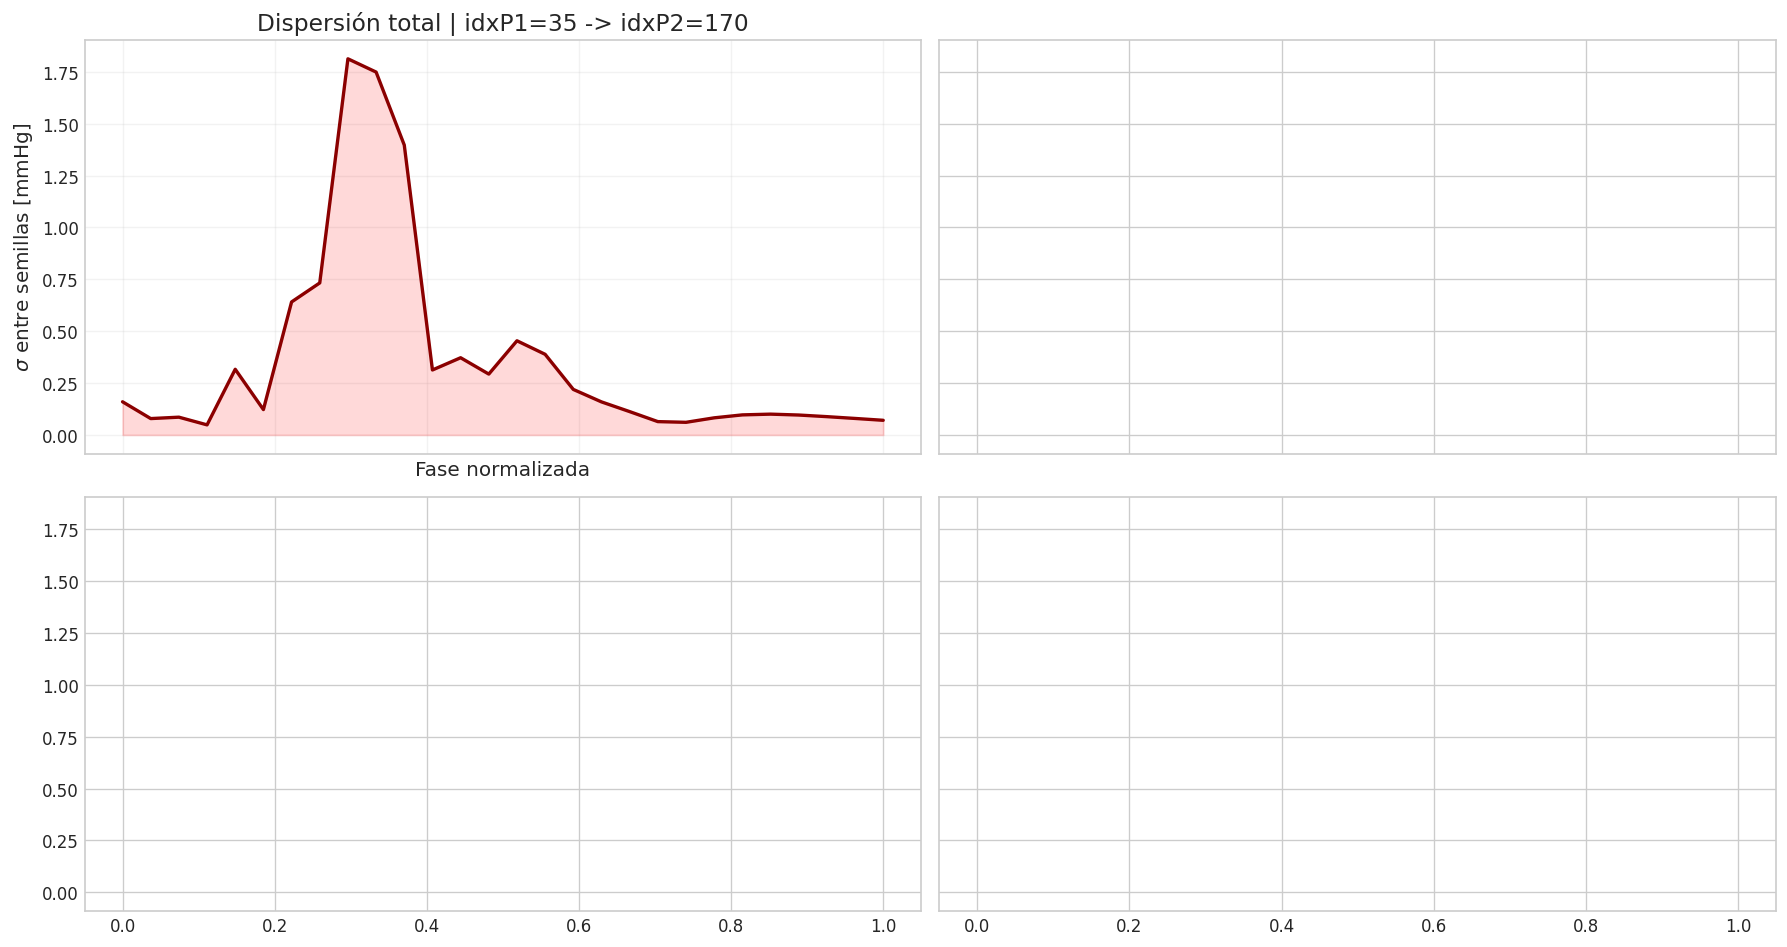

Figura guardada en: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_drop_ensemble_analysis_outputs/pressure_drop_std_all_drops.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, pair in zip(axes, target_drop_pairs):
    analysis = analysis_by_drop[pair]
    phase = analysis["phase"]
    std_total = analysis["stds"]["total"]
    time_s = analysis["time_s"]

    ax.plot(phase, std_total, color="darkred", lw=2)
    ax.fill_between(phase, 0, std_total, color="red", alpha=0.15)
    ax.set_xlabel("Fase normalizada")
    ax.set_ylabel(r"$\sigma$ entre semillas [mmHg]")
    ax.set_title(f"Dispersión total | idxP1={pair[0]} -> idxP2={pair[1]}")
    ax.grid(True, alpha=0.25)

    max_std_idx = int(np.argmax(std_total))
    print(
        f"idxP1={pair[0]}, idxP2={pair[1]} -> desviación máxima "
        f"{std_total[max_std_idx]:.3f} mmHg en fase {phase[max_std_idx]:.3f} "
        f"(t={time_s[max_std_idx]:.4f} s)."
    )

fig.tight_layout()
dispersion_figure_path = output_dir / "pressure_drop_std_all_drops.png"
fig.savefig(dispersion_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {dispersion_figure_path}")

In [12]:
drop_colors = {
    (35, 90): "tab:blue",
    (35, 138): "tab:orange",
    (35, 170): "tab:green",
    (35, 190): "tab:red",
}

scatter_rows = []
peak_rows = []
r2_by_drop = {}

for pair in target_drop_pairs:
    analysis = analysis_by_drop[pair]
    time_s = analysis["time_s"]
    cfd_curve = analysis["clinical"]
    pred_curve = analysis["means"]["total"]
    pred_std = analysis["stds"]["total"]

    residual = pred_curve - cfd_curve
    ss_res = float(np.sum(residual**2))
    ss_tot = float(np.sum((cfd_curve - np.mean(cfd_curve))**2))
    r2_by_drop[pair] = 1.0 - ss_res / max(ss_tot, 1e-12)

    for time_value, cfd_value, pred_value, std_value in zip(time_s, cfd_curve, pred_curve, pred_std):
        scatter_rows.append(
            {
                "drop": f"{pair[0]}->{pair[1]}",
                "idx_p1": pair[0],
                "idx_p2": pair[1],
                "time_s": float(time_value),
                "delta_p_cfd_mmHg": float(cfd_value),
                "delta_p_pred_mean_mmHg": float(pred_value),
                "delta_p_pred_std_mmHg": float(std_value),
            }
        )

    peak_idx_cfd = int(np.argmax(cfd_curve))
    peak_idx_pred = int(np.argmax(pred_curve))
    peak_cfd = float(cfd_curve[peak_idx_cfd])
    peak_pred = float(pred_curve[peak_idx_pred])
    peak_error_percent = 100.0 * (peak_pred - peak_cfd) / max(abs(peak_cfd), 1e-12)

    peak_rows.append(
        {
            "drop": f"{pair[0]}->{pair[1]}",
            "idx_p1": pair[0],
            "idx_p2": pair[1],
            "delta_p_max_cfd_mmHg": peak_cfd,
            "delta_p_max_pred_mmHg": peak_pred,
            "peak_error_percent": peak_error_percent,
            "peak_time_cfd_s": float(time_s[peak_idx_cfd]),
            "peak_time_pred_s": float(time_s[peak_idx_pred]),
            "r2_drop": float(r2_by_drop[pair]),
        }
    )

scatter_df = pd.DataFrame(scatter_rows)
peak_df = pd.DataFrame(peak_rows)

global_residual = scatter_df["delta_p_pred_mean_mmHg"].to_numpy() - scatter_df["delta_p_cfd_mmHg"].to_numpy()
global_ss_res = float(np.sum(global_residual**2))
global_ss_tot = float(np.sum((scatter_df["delta_p_cfd_mmHg"] - scatter_df["delta_p_cfd_mmHg"].mean())**2))
global_r2 = 1.0 - global_ss_res / max(global_ss_tot, 1e-12)

display(scatter_df.head())
display(peak_df)

,drop,idx_p1,idx_p2,time_s,delta_p_cfd_mmHg,delta_p_pred_mean_mmHg,delta_p_pred_std_mmHg
0,35->170,35,170,0.0000,0.029275,0.159510,0.159855
1,35->170,35,170,0.0296,0.550020,0.952011,0.078867
2,35->170,35,170,0.0592,1.790596,2.238374,0.085627
3,35->170,35,170,0.0888,4.695724,4.124724,0.048542
4,35->170,35,170,0.1184,6.746107,6.284317,0.316487


,drop,idx_p1,idx_p2,delta_p_max_cfd_mmHg,delta_p_max_pred_mmHg,peak_error_percent,peak_time_cfd_s,peak_time_pred_s,r2_drop
0,35->170,35,170,6.746107,6.284317,-6.845289,0.1184,0.1184,0.766243


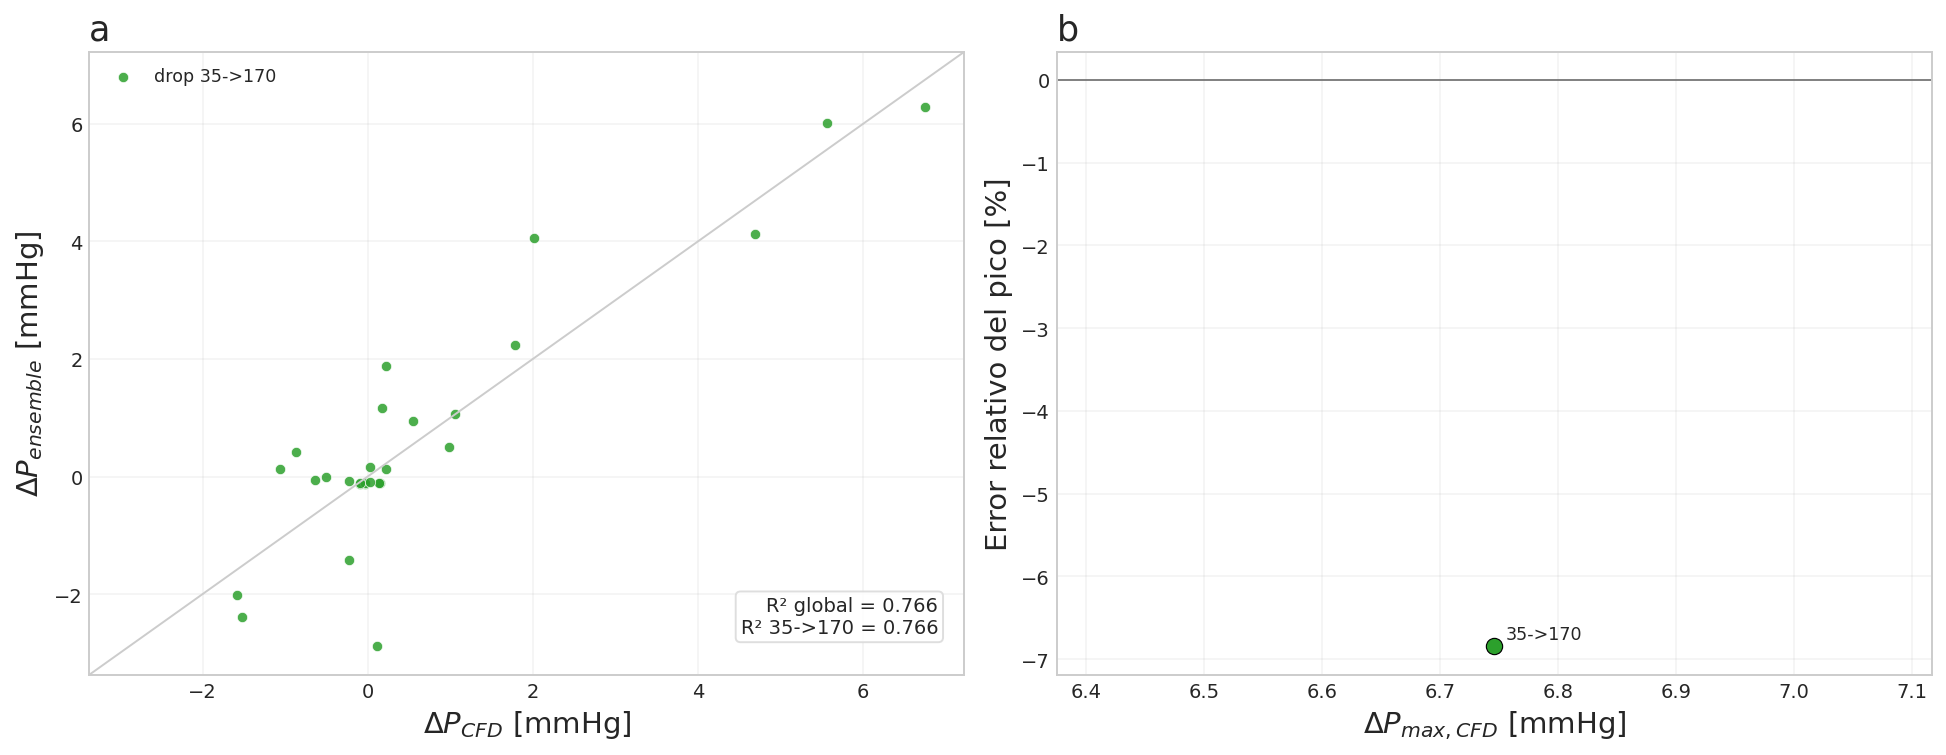

Figura guardada en: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_drop_ensemble_analysis_outputs/pressure_drop_panels_ab_ensemble_mean.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=140)
ax_a, ax_b = axes

for pair in target_drop_pairs:
    drop_label = f"{pair[0]}->{pair[1]}"
    color = drop_colors[pair]
    mask = scatter_df["drop"] == drop_label
    ax_a.scatter(
        scatter_df.loc[mask, "delta_p_cfd_mmHg"],
        scatter_df.loc[mask, "delta_p_pred_mean_mmHg"],
        s=28,
        alpha=0.85,
        color=color,
        edgecolors="white",
        linewidths=0.4,
        label=f"drop {drop_label}"
    )

min_val = float(min(scatter_df["delta_p_cfd_mmHg"].min(), scatter_df["delta_p_pred_mean_mmHg"].min()))
max_val = float(max(scatter_df["delta_p_cfd_mmHg"].max(), scatter_df["delta_p_pred_mean_mmHg"].max()))
pad = 0.05 * (max_val - min_val)
line_vals = np.linspace(min_val - pad, max_val + pad, 200)
ax_a.plot(line_vals, line_vals, color="0.8", lw=1.0)
ax_a.set_xlim(min_val - pad, max_val + pad)
ax_a.set_ylim(min_val - pad, max_val + pad)
ax_a.set_xlabel(r"$\Delta P_{CFD}$ [mmHg]", fontsize=15)
ax_a.set_ylabel(r"$\Delta P_{ensemble}$ [mmHg]", fontsize=15)
ax_a.set_title("a", loc="left", fontsize=18)
ax_a.grid(True, alpha=0.25)
ax_a.legend(loc="upper left", framealpha=0.95, fontsize=9)

annotation_lines = [f"R² global = {global_r2:.3f}"] + [
    f"R² {pair[0]}->{pair[1]} = {r2_by_drop[pair]:.3f}"
    for pair in target_drop_pairs
]
ax_a.text(
    0.97, 0.06,
    "\n".join(annotation_lines),
    transform=ax_a.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.85"),
)

for pair in target_drop_pairs:
    drop_label = f"{pair[0]}->{pair[1]}"
    color = drop_colors[pair]
    row = peak_df.loc[peak_df["drop"] == drop_label].iloc[0]
    ax_b.scatter(
        row["delta_p_max_cfd_mmHg"],
        row["peak_error_percent"],
        s=70,
        color=color,
        edgecolors="black",
        linewidths=0.6,
    )
    ax_b.annotate(
        drop_label,
        (row["delta_p_max_cfd_mmHg"], row["peak_error_percent"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
    )

ax_b.axhline(0.0, color="0.5", lw=1.0)
ax_b.set_xlabel(r"$\Delta P_{max, CFD}$ [mmHg]", fontsize=15)
ax_b.set_ylabel("Error relativo del pico [%]", fontsize=15)
ax_b.set_title("b", loc="left", fontsize=18)
ax_b.grid(True, alpha=0.25)

fig.tight_layout()
comparison_figure_path = output_dir / "pressure_drop_panels_ab_ensemble_mean.png"
fig.savefig(comparison_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {comparison_figure_path}")